# Fine-tune Loss Curve — CarbideMatterGen (HER carbide, Nature-style)

Fine-tunes `mattergen_base` from base with **8 conditioning properties** targeting non-PGM HER electrocatalysts (medium/high-entropy transition-metal carbides with Pt-like ΔG_H*):

- `best_site_h_affinity` — **PRIMARY**. ΔG_H proxy of the most thermoneutral metal site (drive → 0; Sabatier optimum).
- `frac_thermoneutral_sites` — **PRIMARY**. Fraction of metal sites with |ΔG_H| < 0.1 eV (drive → high; the high-entropy "cocktail effect").
- `mean_h_affinity` — composition-weighted mean ΔG_H proxy.
- `metal_mixing_entropy` — metal-sublattice configurational entropy (drive → high, ≥1.5R = HEA).
- `valence_electron_conc` — HEA electronic descriptor (VEC).
- `metal_packing_density` — metallic-framework / conductivity proxy.
- `energy_above_hull`, `dft_band_gap` — base labels: stability + **metallicity (gap → 0)**.

Protocol: `full_finetuning=true`, lr=5e-5, 600 epochs (mirrors OxideMatterGen V6).

Rationale (see `docs/design.md`): HER activity is set by the existence and density of near-thermoneutral active sites, NOT the average. Prior all-strong-binder HEAs (ZrTiHfNbVC) have their entire ΔG_H distribution shifted negative; conditioning on `best_site_h_affinity`→0 + high `metal_mixing_entropy` directly rewards the winning region.

Figures 1–4: loss curves (same panels as the OxideMatterGen notebooks).  
Figure 5: training-set HER-descriptor distributions + metallicity check.

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---- Paths ----
ROOT = Path('/home/jonglee69/mattergen/CarbideMatterGen')
RUN_DIR = ROOT / 'outputs' / 'finetune_carbide'
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# ---- Nature-style rcParams ----
NATURE_RC = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8, 'axes.labelsize': 8, 'axes.titlesize': 9,
    'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'xtick.major.size': 3, 'ytick.major.size': 3,
    'lines.linewidth': 1.0, 'lines.markersize': 3,
    'legend.frameon': False, 'axes.grid': False,
    'axes.spines.top': True, 'axes.spines.right': True,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.bbox': 'tight', 'savefig.dpi': 300,
}
mpl.rcParams.update(NATURE_RC)
# Okabe-Ito colour-blind-safe palette
OI = {'black':'#000000','orange':'#E69F00','skyblue':'#56B4E9','green':'#009E73',
      'yellow':'#F0E442','blue':'#0072B2','vermil':'#D55E00','purple':'#CC79A7'}
print(f'Run dir: {RUN_DIR}')
print(f'Figures: {FIG_DIR}')

Run dir: /home/work/CarbideMatterGen/outputs/finetune_carbide
Figures: /home/work/CarbideMatterGen/figures


In [2]:
# ---- Read wandb offline binary and assemble per-step metrics ----
from wandb.sdk.internal.datastore import DataStore
import wandb.proto.wandb_internal_pb2 as pb

def find_wandb_file(run_dir: Path):
    """Locate the offline wandb binary under <run_dir>/(**/)wandb/offline-run-*/run-*.wandb."""
    cands = sorted(run_dir.rglob('offline-run-*/run-*.wandb'))
    return cands[-1] if cands else None

def read_wandb_history(wandb_path: Path) -> pd.DataFrame:
    """Return a row-per-step DataFrame of all logged metrics."""
    ds = DataStore()
    ds.open_for_scan(str(wandb_path))
    rows = []
    while True:
        rec = ds.scan_data()
        if rec is None:
            break
        record = pb.Record()
        record.ParseFromString(rec)
        if not record.HasField('history'):
            continue
        row = {}
        for item in record.history.item:
            key = item.nested_key[0] if item.nested_key else item.key
            try:
                row[key] = json.loads(item.value_json)
            except Exception:
                pass
        rows.append(row)
    df = pd.DataFrame(rows)
    if '_step' in df.columns:
        df = df.sort_values('_step').reset_index(drop=True)
    return df

wf = find_wandb_file(RUN_DIR)
if wf is None:
    raise SystemExit(f'No wandb file under {RUN_DIR}')
print(f'reading {wf.parent.name}/{wf.name}…')
raw = read_wandb_history(wf)
print(f'raw steps: {len(raw):,}')
epoch_cols = [c for c in raw.columns if c.endswith('_epoch')]
print('epoch-level metrics:', sorted(epoch_cols))

reading offline-run-20260530_101438-mswvxapd/run-mswvxapd.wandb…
raw steps: 1,392
epoch-level metrics: ['atomic_numbers_train_epoch', 'cell_train_epoch', 'loss_train_epoch', 'pos_train_epoch']


In [3]:
# ---- Collapse to one row per (epoch, metric) ----
# *_epoch values are duplicated on every step; keep the LAST value per epoch.
if 'epoch' not in raw.columns:
    raise SystemExit('no "epoch" column found in wandb history yet (training may be early)')
cols = [c for c in raw.columns if raw[c].notna().any()]
by_epoch = (
    raw.dropna(subset=['epoch'])
       .assign(epoch=lambda d: d['epoch'].astype(int))
       .groupby('epoch')
       .agg({c: 'last' for c in cols if c != 'epoch'})
       .reset_index()
       .sort_values('epoch')
)
keep_cols = ['epoch'] + [c for c in [
    'loss_train_epoch', 'loss_val',
    'pos_train_epoch', 'pos_val',
    'cell_train_epoch', 'cell_val',
    'atomic_numbers_train_epoch', 'atomic_numbers_val',
    'lr-Adam',
] if c in by_epoch.columns]
df = by_epoch[keep_cols]
print(f'Collapsed to {len(df)} epochs.')
df.tail(10)

Collapsed to 600 epochs.


,epoch,loss_train_epoch,loss_val,pos_train_epoch,pos_val,cell_train_epoch,cell_val,atomic_numbers_train_epoch,atomic_numbers_val,lr-Adam
590,590,0.216174,0.223301,1.672347,1.597878,0.002663,0.002388,0.046276,0.061125,NaN
591,591,0.190504,0.235697,1.468596,1.755744,0.003644,0.011831,0.040000,0.048292,NaN
592,592,0.189034,0.217562,1.401937,1.399648,0.002523,0.001900,0.046317,0.075697,NaN
593,593,0.193581,0.177662,1.458189,1.103266,0.002765,0.003454,0.044997,0.063881,NaN
594,594,0.210766,0.229668,1.585659,1.512712,0.003231,0.002738,0.048969,0.075659,NaN
595,595,0.192061,0.210921,1.427603,1.509927,0.002160,0.009859,0.047141,0.050069,NaN
596,596,0.191562,0.202767,1.421496,1.307502,0.003397,0.006280,0.046015,0.065736,NaN
597,597,0.223899,0.322677,1.702438,2.777795,0.004335,0.002399,0.049320,0.042499,NaN
598,598,0.187390,0.279864,1.407652,2.117133,0.003514,0.001986,0.043111,0.066165,NaN
599,599,0.197209,0.335557,1.457660,2.586000,0.003464,0.002734,0.047980,0.074223,NaN


In [4]:
# ---- Checkpoint history (val loss recorded in each snapshot filename) ----
ckpts = []
for p in sorted(RUN_DIR.rglob('*.ckpt')):
    m = re.search(r'epoch=(\d+)-loss_val=(\d+\.\d+)', p.name)
    if m:
        ckpts.append({'epoch': int(m.group(1)), 'val_loss_ckpt': float(m.group(2)), 'file': p.name})
ckpt_df = pd.DataFrame(ckpts)
ckpt_df

,epoch,val_loss_ckpt,file
0,526,0.14,epoch=526-loss_val=0.14.ckpt


## Figure 1 — Total loss (train + val)

saved /home/work/CarbideMatterGen/figures/fig1_total_loss_carbide.pdf
saved /home/work/CarbideMatterGen/figures/fig1_total_loss_carbide.png


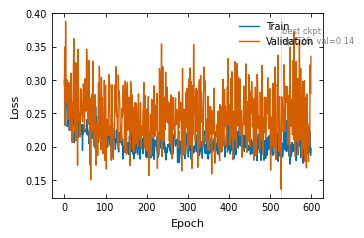

In [5]:
def fig_total_loss(df, ckpt_df, save=True):
    fig, ax = plt.subplots(figsize=(3.5, 2.4))
    sub = df.dropna(subset=['loss_train_epoch'])
    ax.plot(sub['epoch'], sub['loss_train_epoch'],
            color=OI['blue'], label='Train', linewidth=1.0)
    if 'loss_val' in df.columns:
        sv = df.dropna(subset=['loss_val'])
        if len(sv):
            ax.plot(sv['epoch'], sv['loss_val'],
                    color=OI['vermil'], label='Validation', linewidth=1.0)
    if len(ckpt_df):
        best = ckpt_df.sort_values('val_loss_ckpt').iloc[0]
        ax.axvline(best['epoch'], color='gray', linestyle=':', linewidth=0.5)
        ax.text(best['epoch']+3, ax.get_ylim()[1]*0.95,
                f"best ckpt\nep {int(best['epoch'])}, val={best['val_loss_ckpt']:.2f}",
                fontsize=6, color='gray', va='top')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(loc='upper right')
    if save:
        for ext in ('pdf', 'png'):
            out = FIG_DIR / f'fig1_total_loss_carbide.{ext}'
            fig.savefig(out); print(f'saved {out}')
    plt.show()

fig_total_loss(df, ckpt_df)

## Figure 2 — Component losses (position / cell / atomic numbers)

saved /home/work/CarbideMatterGen/figures/fig2_components_carbide.pdf
saved /home/work/CarbideMatterGen/figures/fig2_components_carbide.png


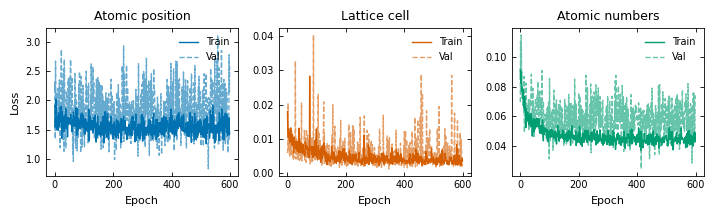

In [6]:
def fig_components(df, save=True):
    fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.2), sharex=True)
    panels = [
        ('Atomic position', 'pos_train_epoch',    'pos_val',    OI['blue']),
        ('Lattice cell',    'cell_train_epoch',   'cell_val',   OI['vermil']),
        ('Atomic numbers',  'atomic_numbers_train_epoch',
                            'atomic_numbers_val',               OI['green']),
    ]
    for ax, (title, kt, kv, c) in zip(axes, panels):
        if kt in df.columns:
            st = df.dropna(subset=[kt])
            if len(st):
                ax.plot(st['epoch'], st[kt], color=c, linewidth=1.0, label='Train')
        if kv in df.columns:
            sv = df.dropna(subset=[kv])
            if len(sv):
                ax.plot(sv['epoch'], sv[kv], color=c, linewidth=1.0,
                        linestyle='--', alpha=0.6, label='Val')
        ax.set_title(title); ax.set_xlabel('Epoch')
        if ax is axes[0]:
            ax.set_ylabel('Loss')
        ax.legend(loc='upper right')
    fig.tight_layout()
    if save:
        for ext in ('pdf', 'png'):
            out = FIG_DIR / f'fig2_components_carbide.{ext}'
            fig.savefig(out); print(f'saved {out}')
    plt.show()

fig_components(df)

## Figure 3 — Log-scale train/val + 5-epoch moving average

saved /home/work/CarbideMatterGen/figures/fig3_loss_logscale_carbide.pdf
saved /home/work/CarbideMatterGen/figures/fig3_loss_logscale_carbide.png


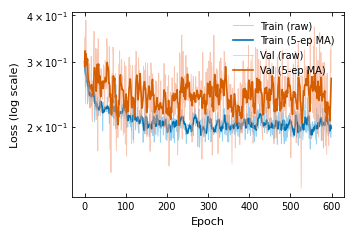

In [7]:
def fig_logscale(df, save=True):
    fig, ax = plt.subplots(figsize=(3.5, 2.4))
    sub = df.dropna(subset=['loss_train_epoch']).copy()
    sub['train_smooth'] = sub['loss_train_epoch'].rolling(5, min_periods=1).mean()
    ax.plot(sub['epoch'], sub['loss_train_epoch'],
            color=OI['skyblue'], linewidth=0.6, alpha=0.6, label='Train (raw)')
    ax.plot(sub['epoch'], sub['train_smooth'],
            color=OI['blue'], linewidth=1.2, label='Train (5-ep MA)')
    if 'loss_val' in df.columns:
        sv = df.dropna(subset=['loss_val']).copy()
        if len(sv):
            sv['val_smooth'] = sv['loss_val'].rolling(5, min_periods=1).mean()
            ax.plot(sv['epoch'], sv['loss_val'],
                    color='#F5A07D', linewidth=0.6, alpha=0.6, label='Val (raw)')
            ax.plot(sv['epoch'], sv['val_smooth'],
                    color=OI['vermil'], linewidth=1.2, label='Val (5-ep MA)')
    ax.set_yscale('log')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log scale)')
    ax.legend(loc='upper right')
    if save:
        for ext in ('pdf', 'png'):
            out = FIG_DIR / f'fig3_loss_logscale_carbide.{ext}'
            fig.savefig(out); print(f'saved {out}')
    plt.show()

fig_logscale(df)

## Figure 4 — Composite 2×2 panel (paper main figure)

Combines component losses (a–c) and total log-scale loss (d) for a single double-column publication figure (183 mm / 7.2 inch).

saved /home/work/CarbideMatterGen/figures/fig4_composite_carbide.pdf
saved /home/work/CarbideMatterGen/figures/fig4_composite_carbide.png


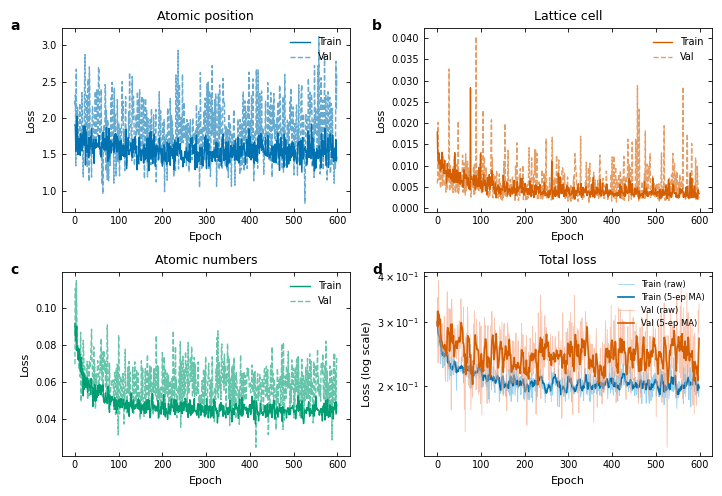

In [8]:
def fig_composite(df, ckpt_df, save=True):
    fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.0))
    ax_pos, ax_cell, ax_atom, ax_total = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

    # --- (a) Atomic position ---
    if 'pos_train_epoch' in df.columns:
        st = df.dropna(subset=['pos_train_epoch'])
        ax_pos.plot(st['epoch'], st['pos_train_epoch'], color=OI['blue'], linewidth=1.0, label='Train')
    if 'pos_val' in df.columns:
        sv = df.dropna(subset=['pos_val'])
        ax_pos.plot(sv['epoch'], sv['pos_val'], color=OI['blue'], linewidth=1.0, linestyle='--', alpha=0.6, label='Val')
    ax_pos.set_title('Atomic position'); ax_pos.set_xlabel('Epoch'); ax_pos.set_ylabel('Loss')
    ax_pos.legend(loc='upper right')

    # --- (b) Lattice cell ---
    if 'cell_train_epoch' in df.columns:
        st = df.dropna(subset=['cell_train_epoch'])
        ax_cell.plot(st['epoch'], st['cell_train_epoch'], color=OI['vermil'], linewidth=1.0, label='Train')
    if 'cell_val' in df.columns:
        sv = df.dropna(subset=['cell_val'])
        ax_cell.plot(sv['epoch'], sv['cell_val'], color=OI['vermil'], linewidth=1.0, linestyle='--', alpha=0.6, label='Val')
    ax_cell.set_title('Lattice cell'); ax_cell.set_xlabel('Epoch'); ax_cell.set_ylabel('Loss')
    ax_cell.legend(loc='upper right')

    # --- (c) Atomic numbers ---
    if 'atomic_numbers_train_epoch' in df.columns:
        st = df.dropna(subset=['atomic_numbers_train_epoch'])
        ax_atom.plot(st['epoch'], st['atomic_numbers_train_epoch'], color=OI['green'], linewidth=1.0, label='Train')
    if 'atomic_numbers_val' in df.columns:
        sv = df.dropna(subset=['atomic_numbers_val'])
        ax_atom.plot(sv['epoch'], sv['atomic_numbers_val'], color=OI['green'], linewidth=1.0, linestyle='--', alpha=0.6, label='Val')
    ax_atom.set_title('Atomic numbers'); ax_atom.set_xlabel('Epoch'); ax_atom.set_ylabel('Loss')
    ax_atom.legend(loc='upper right')

    # --- (d) Total loss, log scale + 5-ep MA ---
    st = df.dropna(subset=['loss_train_epoch']).copy()
    st['train_smooth'] = st['loss_train_epoch'].rolling(5, min_periods=1).mean()
    ax_total.plot(st['epoch'], st['loss_train_epoch'], color=OI['skyblue'], linewidth=0.6, alpha=0.6, label='Train (raw)')
    ax_total.plot(st['epoch'], st['train_smooth'], color=OI['blue'], linewidth=1.2, label='Train (5-ep MA)')
    if 'loss_val' in df.columns:
        sv = df.dropna(subset=['loss_val']).copy()
        if len(sv):
            sv['val_smooth'] = sv['loss_val'].rolling(5, min_periods=1).mean()
            ax_total.plot(sv['epoch'], sv['loss_val'], color='#F5A07D', linewidth=0.6, alpha=0.6, label='Val (raw)')
            ax_total.plot(sv['epoch'], sv['val_smooth'], color=OI['vermil'], linewidth=1.2, label='Val (5-ep MA)')
    ax_total.set_yscale('log')
    ax_total.set_title('Total loss')
    ax_total.set_xlabel('Epoch'); ax_total.set_ylabel('Loss (log scale)')
    ax_total.legend(loc='upper right', fontsize=6)

    for ax, lbl in zip([ax_pos, ax_cell, ax_atom, ax_total], ['a','b','c','d']):
        ax.text(-0.18, 1.05, lbl, transform=ax.transAxes,
                fontsize=10, fontweight='bold', va='top', ha='left')

    fig.tight_layout()
    if save:
        for ext in ('pdf', 'png'):
            out = FIG_DIR / f'fig4_composite_carbide.{ext}'
            fig.savefig(out); print(f'saved {out}')
    plt.show()

fig_composite(df, ckpt_df)

## Summary statistics

In [9]:
if len(df):
    first = df.iloc[0]
    last  = df.iloc[-1]
    print(f"Epochs parsed      : {len(df)}")
    if pd.notna(first.get('loss_train_epoch')):
        print(f"Train loss (start) : {first.loss_train_epoch:.4f}")
        print(f"Train loss (last)  : {last.loss_train_epoch:.4f}  (epoch {int(last.epoch)})")
    if 'loss_val' in df.columns and df['loss_val'].notna().any():
        v = df['loss_val']
        print(f"Val loss (start)   : {v.dropna().iloc[0]:.4f}")
        print(f"Val loss (last)    : {v.dropna().iloc[-1]:.4f}")
        bi = v.idxmin()
        print(f"Val loss (best)    : {v.min():.4f}  (epoch {int(df.loc[bi,'epoch'])})")
    if pd.notna(first.get('loss_train_epoch')) and pd.notna(last.get('loss_train_epoch')):
        drop = (first.loss_train_epoch - last.loss_train_epoch) / first.loss_train_epoch * 100
        print(f"Train loss drop    : {drop:.1f}%")
    for name in ('atomic_numbers_train_epoch', 'pos_train_epoch', 'cell_train_epoch'):
        if name in df.columns and df[name].notna().any():
            s = df[name].dropna()
            print(f'{name:<28}: {s.iloc[0]:.4f} → {s.iloc[-1]:.4f}')

Epochs parsed      : 600
Train loss (start) : 0.2997
Train loss (last)  : 0.1972  (epoch 599)
Val loss (start)   : 0.2923
Val loss (last)    : 0.3356
Val loss (best)    : 0.1366  (epoch 526)
Train loss drop    : 34.2%
atomic_numbers_train_epoch  : 0.0914 → 0.0480
pos_train_epoch             : 1.9039 → 1.4577
cell_train_epoch            : 0.0179 → 0.0035


## Figure 5 — Training-set statistics (HER descriptors, metallicity, entropy)

Distribution of the physics labels in the labeled carbide training set
(`data/carbide_labeled_train.csv`). This answers, before any generation:

- Where does the thermoneutral target (`best_site_h_affinity` ≈ 0) sit in the training distribution?
- Are carbides actually metallic (`dft_band_gap` → 0), i.e. is the conductivity requirement already satisfied by the chemistry?
- How are entropy (`metal_mixing_entropy`) and the HER target coupled — does mixing help reach ΔG_H ≈ 0?
- Which composition descriptor (VEC, d-band proxy) best tracks the H-affinity?

Produced as a single 3×3 double-column figure (`figures/fig5_training_stats_carbide.{pdf,png}`).

loaded 5,275 carbide rows
saved /home/work/CarbideMatterGen/figures/fig5_training_stats_carbide.pdf
saved /home/work/CarbideMatterGen/figures/fig5_training_stats_carbide.png


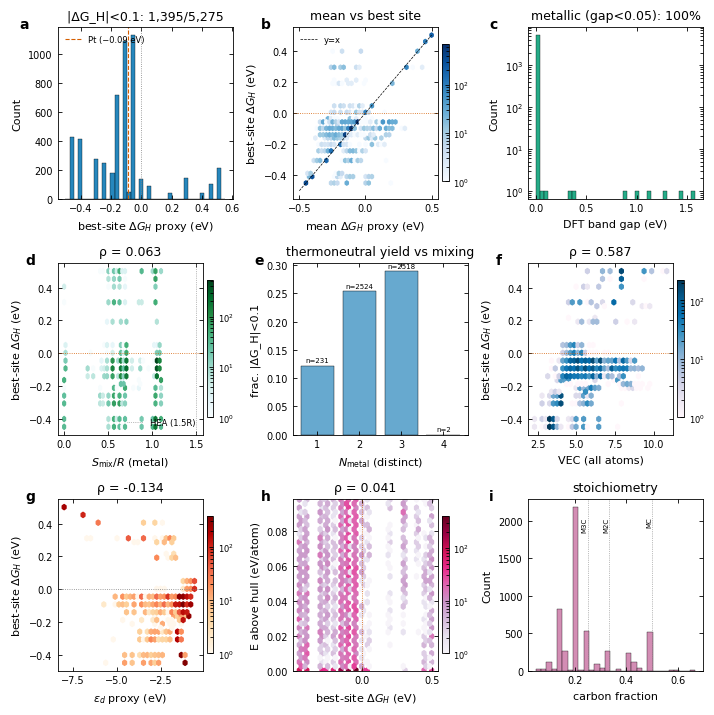

In [10]:
from scipy.stats import spearmanr
from matplotlib.colors import LogNorm

lbl = pd.read_csv(ROOT / 'data' / 'carbide_labeled_train.csv')
print(f'loaded {len(lbl):,} carbide rows')

def rho(x, y):
    m = x.notna() & y.notna()
    return spearmanr(x[m], y[m]).statistic if m.sum() >= 20 else float('nan')

# Metallicity: carbides should be metallic. gap==0 => metallic.
has_gap = 'dft_band_gap' in lbl.columns and lbl['dft_band_gap'].notna().any()
if has_gap:
    lbl['is_metallic'] = lbl['dft_band_gap'].fillna(0) < 0.05
TN = 0.10  # thermoneutral window (eV)
lbl['near_thermoneutral'] = lbl['best_site_h_affinity'].abs() < TN

bins_h = np.linspace(-0.5, 0.55, 40)

fig, axes = plt.subplots(3, 3, figsize=(7.2, 7.2))
for ax, ch in zip(axes.flat, list('abcdefghi')):
    ax.text(-0.22, 1.06, ch, transform=ax.transAxes, fontsize=10,
            fontweight='bold', va='top', ha='left')

# (a) best_site_h_affinity distribution + Pt reference
ax = axes[0,0]
ax.hist(lbl['best_site_h_affinity'].dropna(), bins=bins_h, color=OI['blue'],
        edgecolor='black', linewidth=0.3, alpha=0.85)
ax.axvline(0.0, color='gray', linestyle=':', linewidth=0.6)
ax.axvline(-0.09, color=OI['vermil'], linestyle='--', linewidth=0.8, label='Pt (−0.09 eV)')
n_tn = int(lbl['near_thermoneutral'].sum())
ax.set_xlabel(r'best-site $\Delta G_H$ proxy (eV)'); ax.set_ylabel('Count')
ax.set_title(f'|ΔG_H|<{TN}: {n_tn:,}/{len(lbl):,}'); ax.legend(loc='upper left', fontsize=6)

# (b) mean vs best site H-affinity
ax = axes[0,1]
hb = ax.hexbin(lbl['mean_h_affinity'], lbl['best_site_h_affinity'],
               gridsize=40, mincnt=1, cmap='Blues', norm=LogNorm())
ax.plot([-0.5,0.5],[-0.5,0.5],'k--',linewidth=0.5,label='y=x')
ax.axhline(0.0, color=OI['vermil'], linestyle=':', linewidth=0.6)
ax.set_xlabel(r'mean $\Delta G_H$ proxy (eV)'); ax.set_ylabel(r'best-site $\Delta G_H$ (eV)')
ax.set_title('mean vs best site'); ax.legend(loc='upper left', fontsize=6)
fig.colorbar(hb, ax=ax, shrink=0.8, pad=0.02).ax.tick_params(labelsize=6)

# (c) metallicity: band-gap distribution (carbides should pile at 0)
ax = axes[0,2]
if has_gap:
    ax.hist(lbl['dft_band_gap'].fillna(0), bins=40, color=OI['green'],
            edgecolor='black', linewidth=0.3, alpha=0.85)
    frac_met = float(lbl['is_metallic'].mean())
    ax.set_title(f'metallic (gap<0.05): {100*frac_met:.0f}%')
else:
    ax.text(0.5,0.5,'no dft_band_gap', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('metallicity')
ax.set_xlabel('DFT band gap (eV)'); ax.set_ylabel('Count'); ax.set_yscale('log')

# (d) entropy vs best-site H-affinity (does mixing reach thermoneutral?)
ax = axes[1,0]
hb = ax.hexbin(lbl['metal_mixing_entropy'], lbl['best_site_h_affinity'],
               gridsize=35, mincnt=1, cmap='BuGn', norm=LogNorm())
ax.axhline(0.0, color=OI['vermil'], linestyle=':', linewidth=0.6)
ax.axvline(1.5, color='gray', linestyle=':', linewidth=0.5, label='HEA (1.5R)')
ax.set_xlabel(r'$S_{\mathrm{mix}}/R$ (metal)'); ax.set_ylabel(r'best-site $\Delta G_H$ (eV)')
ax.set_title(f'ρ = {rho(lbl["metal_mixing_entropy"], lbl["best_site_h_affinity"]):.3f}')
ax.legend(loc='lower right', fontsize=6)
fig.colorbar(hb, ax=ax, shrink=0.8, pad=0.02).ax.tick_params(labelsize=6)

# (e) n_metal_species: fraction near-thermoneutral by metal count
ax = axes[1,1]
nm_vals = sorted(int(v) for v in lbl['n_metal_species'].dropna().unique() if 1 <= v <= 6)
frac_tn = [float(lbl.loc[lbl['n_metal_species']==v, 'near_thermoneutral'].mean()) for v in nm_vals]
cnt = [int((lbl['n_metal_species']==v).sum()) for v in nm_vals]
bars = ax.bar(nm_vals, frac_tn, color='#67A9CF', edgecolor='black', linewidth=0.3)
for b, n in zip(bars, cnt):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'n={n}',
            ha='center', va='bottom', fontsize=5)
ax.set_xlabel(r'$N_{\mathrm{metal}}$ (distinct)'); ax.set_ylabel(f'frac. |ΔG_H|<{TN}')
ax.set_title('thermoneutral yield vs mixing')

# (f) VEC vs best-site H-affinity
ax = axes[1,2]
hb = ax.hexbin(lbl['valence_electron_conc'], lbl['best_site_h_affinity'],
               gridsize=35, mincnt=1, cmap='PuBu', norm=LogNorm())
ax.axhline(0.0, color=OI['vermil'], linestyle=':', linewidth=0.6)
ax.set_xlabel('VEC (all atoms)'); ax.set_ylabel(r'best-site $\Delta G_H$ (eV)')
ax.set_title(f'ρ = {rho(lbl["valence_electron_conc"], lbl["best_site_h_affinity"]):.3f}')
fig.colorbar(hb, ax=ax, shrink=0.8, pad=0.02).ax.tick_params(labelsize=6)

# (g) d-band proxy vs best-site H-affinity (Hammer-Norskov)
ax = axes[2,0]
hb = ax.hexbin(lbl['d_band_proxy'], lbl['best_site_h_affinity'],
               gridsize=35, mincnt=1, cmap='OrRd', norm=LogNorm())
ax.axhline(0.0, color='gray', linestyle=':', linewidth=0.6)
ax.set_xlabel(r'$\varepsilon_d$ proxy (eV)'); ax.set_ylabel(r'best-site $\Delta G_H$ (eV)')
ax.set_title(f'ρ = {rho(lbl["d_band_proxy"], lbl["best_site_h_affinity"]):.3f}')
fig.colorbar(hb, ax=ax, shrink=0.8, pad=0.02).ax.tick_params(labelsize=6)

# (h) stability vs best-site H-affinity
ax = axes[2,1]
if 'energy_above_hull' in lbl.columns:
    eh_max = float(lbl['energy_above_hull'].quantile(0.99))
    hb = ax.hexbin(lbl['best_site_h_affinity'], lbl['energy_above_hull'].clip(upper=eh_max),
                   gridsize=35, mincnt=1, cmap='PuRd', norm=LogNorm())
    ax.axvline(0.0, color=OI['vermil'], linestyle=':', linewidth=0.6)
    ax.set_ylim(0, eh_max)
    ax.set_xlabel(r'best-site $\Delta G_H$ (eV)'); ax.set_ylabel('E above hull (eV/atom)')
    ax.set_title(f'ρ = {rho(lbl["best_site_h_affinity"], lbl["energy_above_hull"]):.3f}')
    fig.colorbar(hb, ax=ax, shrink=0.8, pad=0.02).ax.tick_params(labelsize=6)
else:
    ax.set_axis_off()

# (i) carbon fraction distribution (MC / M2C / M3C stoichiometry)
ax = axes[2,2]
ax.hist(lbl['carbon_fraction'].dropna(), bins=30, color=OI['purple'],
        edgecolor='black', linewidth=0.3, alpha=0.85)
for x, t in [(1/3,'M2C'), (1/2,'MC'), (1/4,'M3C')]:
    ax.axvline(x, color='gray', linestyle=':', linewidth=0.5)
    ax.text(x, ax.get_ylim()[1]*0.9, t, fontsize=5, rotation=90, va='top', ha='right')
ax.set_xlabel('carbon fraction'); ax.set_ylabel('Count')
ax.set_title('stoichiometry')

fig.tight_layout()
for ext in ('pdf', 'png'):
    out = FIG_DIR / f'fig5_training_stats_carbide.{ext}'
    fig.savefig(out); print(f'saved {out}')
plt.show()

### Target-value reality check

Where do the Stage-A generation targets (best_site ≈ 0, frac_thermoneutral → 1, S_mix → 1.6, gap → 0) sit in the training distribution? This tells us how far classifier-free guidance must extrapolate.

In [11]:
print('=== Generation targets vs training-distribution quantiles ===')
targets = {
    'best_site_h_affinity': 0.0,
    'frac_thermoneutral_sites': 1.0,
    'metal_mixing_entropy': 1.6,
    'valence_electron_conc': 6.0,
}
for k, t in targets.items():
    if k not in lbl.columns:
        continue
    v = lbl[k].dropna()
    pct = (v <= t).mean() * 100
    print(f'  {k:<26} target={t:>5} | training P{pct:5.1f}%   median={v.median():.3f}   max={v.max():.3f}')

print()
print('=== Spearman ρ of HER descriptors vs best_site_h_affinity ===')
for feat in ['mean_h_affinity','metal_mixing_entropy','valence_electron_conc',
             'd_band_proxy','carbon_fraction','n_metal_species']:
    if feat in lbl.columns:
        print(f'  {feat:<26}: {rho(lbl[feat], lbl["best_site_h_affinity"]):+.3f}')

if 'energy_above_hull' in lbl.columns:
    print()
    print('=== Spearman ρ vs energy_above_hull (stability) ===')
    for feat in ['best_site_h_affinity','metal_mixing_entropy','n_metal_species','metal_packing_density']:
        if feat in lbl.columns:
            print(f'  {feat:<26}: {rho(lbl[feat], lbl["energy_above_hull"]):+.3f}')

n5 = int((lbl['n_metal_species'] >= 5).sum()) if 'n_metal_species' in lbl.columns else 0
print()
print(f'NOTE: training set has {n5} structures with >=5 distinct metals.')
print('True 5-metal HEA carbides are out-of-distribution -> must come from guided generation, not memorization.')

=== Generation targets vs training-distribution quantiles ===
  best_site_h_affinity       target=  0.0 | training P 88.2%   median=-0.100   max=0.500
  frac_thermoneutral_sites   target=  1.0 | training P100.0%   median=0.000   max=1.000
  metal_mixing_entropy       target=  1.6 | training P100.0%   median=0.693   max=1.099
  valence_electron_conc      target=  6.0 | training P 69.5%   median=5.400   max=10.857

=== Spearman ρ of HER descriptors vs best_site_h_affinity ===
  mean_h_affinity           : +0.763
  metal_mixing_entropy      : +0.063
  valence_electron_conc     : +0.587
  d_band_proxy              : -0.134
  carbon_fraction           : -0.025
  n_metal_species           : +0.033

=== Spearman ρ vs energy_above_hull (stability) ===
  best_site_h_affinity      : +0.041
  metal_mixing_entropy      : -0.063
  n_metal_species           : +0.001
  metal_packing_density     : +0.109

NOTE: training set has 0 structures with >=5 distinct metals.
True 5-metal HEA carbides are out-o